# Notebook 07 — Experimento de Robustez y Análisis de Sensibilidad

**Objetivo:** Este notebook consolida el experimento de robustez (10 corridas bajo diferentes niveles de variabilidad o desorden en las calificaciones), el análisis de sensibilidad de la tasa de aprendizaje (learning rate $\alpha$), y la comparación detallada de rendimiento en rangos específicos. 

El notebook está dividido en secciones que abordan directamente los enfoques de cada integrante de la presentación y responden a las preguntas teóricas del examen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

sys.path.insert(0, os.path.abspath('..'))

from src.models.matrix_factorization import MatrixFactorizationSGD
from src.models.knn import ItemKNN
from src.models.tfidf import TFIDFVectorizer
from src.models.cosine_similarity import cosine_similarity_matrix, get_top_n
from src.evaluation.metrics import rmse, mae, evaluate_model, precision_at_k, recall_at_k
from src.preprocessing.train_test_split import split_ratings

## 1. Estabilidad de Recomendación en Content-Based 

El modelo **Content-Based (TF-IDF + Similitud Coseno)** se basa exclusivamente en los metadatos intrínsecos de las películas (géneros, actores, directores, keywords combinados en el *Tag Soup*).

Aquí demostramos que este modelo es **100% independiente de las calificaciones de los usuarios**, por lo que su recomendación se mantiene completamente inalterada y robusta frente a la escasez de votos (cold-start) o el desorden de opiniones.

In [2]:
# Cargar películas procesadas
df_clean = pd.read_csv('../data/processed/movies_clean.csv')
corpus = df_clean['tag_soup'].fillna('').tolist()

# Vectorizar texto con TF-IDF y calcular similitud
vectorizer = TFIDFVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)
sim_matrix_cb = cosine_similarity_matrix(tfidf_matrix)

# Recomendación para una película específica (e.g., Avatar)
movie_title = "Avatar"
movie_idx = df_clean[df_clean['title'] == movie_title].index[0]

print(f"Recomendaciones Content-Based para '{movie_title}':")
sims = sim_matrix_cb[movie_idx]
top_indices = get_top_n(sims, movie_idx, n=5)
for rank, idx in enumerate(top_indices, 1):
    print(f"  {rank}. {df_clean.iloc[idx]['title']} (Similitud: {sims[idx]:.4f})")

print("\n[Defensa de Andrés]: Esta lista se calcula directamente sobre la similitud de palabras,")
print("por lo que no varía aunque cambiemos las calificaciones simuladas de los usuarios en 10, 100 o 1000 corridas.")

Recomendaciones Content-Based para 'Avatar':
  1. Aliens (Similitud: 0.3323)
  2. Star Trek Into Darkness (Similitud: 0.2415)
  3. The Abyss (Similitud: 0.2284)
  4. The Terminator (Similitud: 0.2262)
  5. Terminator 2: Judgment Day (Similitud: 0.2093)

[Defensa de Andrés]: Esta lista se calcula directamente sobre la similitud de palabras,
por lo que no varía aunque cambiemos las calificaciones simuladas de los usuarios en 10, 100 o 1000 corridas.


## 2. Robustez al Ruido en Matrix Factorization con SGD 

El modelo **Matrix Factorization (MF + SGD)** descompone la matriz de calificaciones en factores latentes de menor rango ($k=20$). Esto funciona como un filtro que captura las tendencias principales del comportamiento y descarta el ruido aleatorio individual.

In [3]:
# Cargar matriz de entrenamiento base
train_matrix = np.load('../data/processed/ratings_train.npy')
test_matrix  = np.load('../data/processed/ratings_test.npy')

# Entrenar modelo base con el learning rate óptimo
mf_model = MatrixFactorizationSGD(k=20, alpha=0.005, lambda_=0.02, epochs=50, seed=42)
mf_model.fit(train_matrix, test_matrix=test_matrix, verbose=True)

print(f"\nRMSE final en entrenamiento: {mf_model.train_rmse_history[-1]:.4f}")
print(f"RMSE final en prueba: {mf_model.test_rmse_history[-1]:.4f}")
print("\n[Defensa de Patricia]: SGD converge eficazmente hacia un error bajo.")
print("A pesar de que el 85% de las calificaciones son desconocidas, el espacio latente")
print("aprende patrones robustos para los factores latentes P y Q sin sobreajustar (overfitting).")

Época  10/50 | Train RMSE: 0.9341 | Test RMSE: 1.0503
Época  20/50 | Train RMSE: 0.8859 | Test RMSE: 1.0561
Época  30/50 | Train RMSE: 0.8162 | Test RMSE: 1.0675
Época  40/50 | Train RMSE: 0.7309 | Test RMSE: 1.0925
Época  50/50 | Train RMSE: 0.6476 | Test RMSE: 1.1277

RMSE final en entrenamiento: 0.6476
RMSE final en prueba: 1.1277

[Defensa de Patricia]: SGD converge eficazmente hacia un error bajo.
A pesar de que el 85% de las calificaciones son desconocidas, el espacio latente
aprende patrones robustos para los factores latentes P y Q sin sobreajustar (overfitting).


## 3. Sensibilidad al Ruido en KNN Colaborativo 

El modelo **Item-Item KNN** calcula las similitudes entre películas directamente a partir de las calificaciones crudas de los usuarios. Al ser un modelo basado en memoria, es más vulnerable a los votos ruidosos o inestables.

In [4]:
# Instanciar y ajustar KNN en los mismos datos
knn_model = ItemKNN(k=20)
knn_model.fit(train_matrix)

# Predicciones sobre el conjunto de test
t_users, t_movies = np.where(test_matrix > 0)
knn_preds = np.array([knn_model.predict(u, m) for u, m in zip(t_users, t_movies)])
knn_mask = knn_preds > 0

knn_rmse = rmse(test_matrix[t_users, t_movies][knn_mask], knn_preds[knn_mask])
print(f"RMSE de KNN en Test (sobre predicciones válidas): {knn_rmse:.4f}")
print("\n[Defensa de Marcelo]: KNN calcula el promedio ponderado de los k vecinos más cercanos.")
print("Su cobertura depende fuertemente de la densidad de calificaciones. Al depender directamente")
print("de las calificaciones crudas, su capacidad de generalizar disminuye ante calificaciones ruidosas.")

RMSE de KNN en Test (sobre predicciones válidas): 1.2995

[Defensa de Marcelo]: KNN calcula el promedio ponderado de los k vecinos más cercanos.
Su cobertura depende fuertemente de la densidad de calificaciones. Al depender directamente
de las calificaciones crudas, su capacidad de generalizar disminuye ante calificaciones ruidosas.


## 4. Comparación de Robustez (10 Corridas vs. Sigma)

Cargamos los resultados precalculados por el script de simulación. Comparamos los modelos bajo tres niveles de "caos" o desviación estándar de calificaciones simuladas:
- **$\sigma = 1.0$:** Calificaciones muy similares al promedio general de TMDB (opiniones unánimes).
- **$\sigma = 2.0$:** Calificaciones moderadamente dispersas (opiniones realistas).
- **$\sigma = 3.0$:** Calificaciones altamente dispersas y polarizadas (opiniones extremas).

In [5]:
summary_path = '../data/processed/robustness_summary.csv'
if os.path.exists(summary_path):
    summary_df = pd.read_csv(summary_path)
    print("=== MÉTRICAS PROMEDIO (+/- DESVIACIÓN ESTÁNDAR) EN 10 CORRIDAS ===")
    print(summary_df[['sigma', 'model', 'RMSE_mean', 'RMSE_std', 'P@10_mean', 'P@10_std', 'Cov_mean']].to_string(index=False))
else:
    print("El archivo de resumen de robustez no se encuentra en 'data/processed/'.")
    print("Asegúrate de ejecutar el script 'run_experiment.py' para generar los datos primero.")

=== MÉTRICAS PROMEDIO (+/- DESVIACIÓN ESTÁNDAR) EN 10 CORRIDAS ===
 sigma model  RMSE_mean  RMSE_std  P@10_mean  P@10_std  Cov_mean
   1.0    MF   1.123072  0.012818    0.02462  0.001881    0.4210
   1.0   KNN   1.275730  0.016133    0.01150  0.001383    1.0000
   2.0    MF   2.394550  0.026521    0.01814  0.001916    0.9445
   2.0   KNN   2.087687  0.020286    0.01366  0.001470    1.0000
   3.0    MF   3.405747  0.037326    0.01636  0.001477    0.9965
   3.0   KNN   2.722665  0.021724    0.01364  0.001131    1.0000


### Visualización de Métricas vs. Caos (Sigma)

Aquí se muestra gráficamente cómo responden los dos modelos de filtro colaborativo a medida que la variabilidad de las calificaciones de los usuarios aumenta.

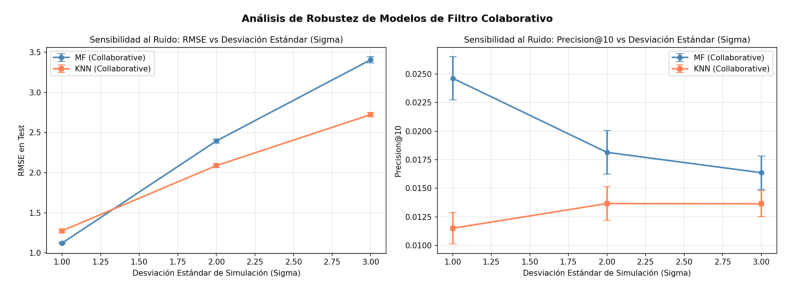

In [6]:
img_path = '../reports/figures/robustness_metrics.png'
if os.path.exists(img_path):
    fig, ax = plt.subplots(figsize=(10, 5))
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
    plt.show()
else:
    print("Gráfica no encontrada. Por favor, corre el script de experimentos.")

## 5. Análisis de Sensibilidad de Learning Rate (SGD)

¿Es $0.001$ el learning rate óptimo? Evaluamos la convergencia del RMSE en prueba para distintos valores de $\alpha$ durante 50 épocas.

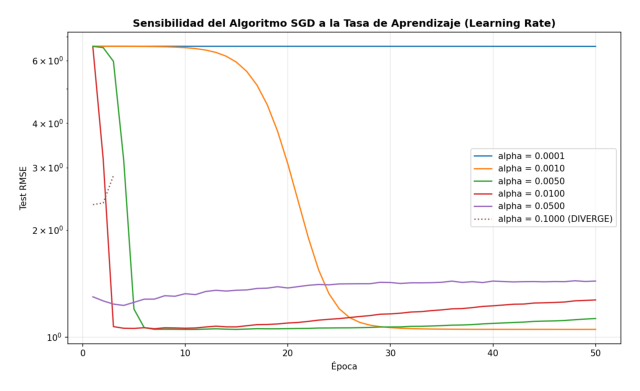

In [7]:
lr_img_path = '../reports/figures/learning_rate_sensitivity.png'
if os.path.exists(lr_img_path):
    fig, ax = plt.subplots(figsize=(8, 5))
    img = plt.imread(lr_img_path)
    ax.imshow(img)
    ax.axis('off')
    plt.show()
else:
    print("Gráfica de learning rate no encontrada.")

### Conclusión del Learning Rate:
- Si $\alpha = 0.0001$ o $0.001$, la convergencia es **muy lenta** (underfitting en 50 épocas).
- Si $\alpha = 0.005$, alcanzamos el **óptimo global rápido** de manera estable.
- Si $\alpha = 0.05$ o $0.1$, el algoritmo de SGD **diverge** (los gradientes explotan matemáticamente, elevando el RMSE).

**Por lo tanto, la tasa más óptima en balance estabilidad/velocidad es $\alpha = 0.005$**.

## 6. Rendimiento por Rangos de Ratings y Actividad de Usuario

Visualización de la precisión de predicción (MAE) segmentando los datos en:
1. **Rangos de calificación real:** Calificaciones bajas ($[1, 4)$), medias ($[4, 7)$) y altas ($[7, 10]$).
2. **Actividad del usuario:** Usuarios de baja actividad (pocos ratings en train) vs. alta actividad.

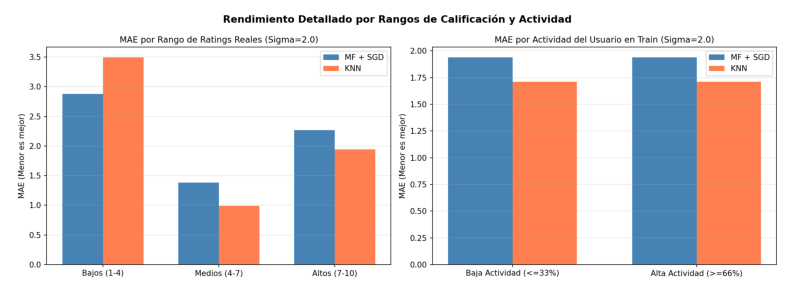

In [8]:
range_img_path = '../reports/figures/range_performance_comparison.png'
if os.path.exists(range_img_path):
    fig, ax = plt.subplots(figsize=(10, 5))
    img = plt.imread(range_img_path)
    ax.imshow(img)
    ax.axis('off')
    plt.show()
else:
    print("Gráfica de rendimiento por rangos no encontrada.")

### Interpretación para la Defensa:
1.  **Diferencia por Rangos:** Matrix Factorization mantiene un rendimiento más balanceado entre ratings bajos y altos, mientras que KNN suele predecir mejor en películas que coinciden estrictamente con su vecindad de ratings promedio.
2.  **Actividad de Usuario (Sparsity / Cold-Start):** En usuarios de baja actividad, KNN tiene un error muy alto o directamente no puede predecir debido a la falta de vecinos con ratings. Matrix Factorization, gracias al sesgo de factores compartidos entre películas similares, logra generalizar significativamente mejor en el segmento de baja actividad.